In [97]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import pickle
from scipy.ndimage import zoom
import sigpy as sp
import cupy as cp
import numpy as np
from numpy import fft
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import butter,filtfilt
from admm.utils_moco import stacked_nufft_operator,golden_angle_2d_readout, golden_angle_coords_3d, pocs, phase_based_gating_peak_to_peak, phase_based_gating, create_gates
from scipy import ndimage
import napari
import nibabel as nib

def rotate_90(img):
    return ndimage.rotate(img,90)

## Load all data

In [98]:
## Load channel recons for high resolution data

data_dir_highres = '/home/lilianae/projects/data/processed/'

recon_all_channels = 'mid00118_all_channels_recon'

with open(os.path.join(data_dir_highres, recon_all_channels), 'rb') as f:
    recon_all_channels_loaded = pickle.load(f)

print(f'recon_all_channels_loaded.shape = {recon_all_channels_loaded.shape}')

recon_all_channels_loaded.shape = (15, 58, 256, 256)


In [99]:
## Load low res data from AdjCoilSens

data_dir_lowres = '/home/lilianae/projects/data/processed/'

adjcoilsens_all_recons = 'adjcoilsens_all_recons.pkl'
adjcoilsens_sos = 'adjcoilsens_sos.pkl'

with open(os.path.join(data_dir_lowres, adjcoilsens_all_recons), 'rb') as f:
    low_res_coil_recons = pickle.load(f)


with open(os.path.join(data_dir_lowres, adjcoilsens_sos), 'rb') as f:
    low_res_sos = pickle.load(f)

print(f'low_res_coil_recons.shape = {low_res_coil_recons.shape}')
print(f'low_res_sos.shape = {low_res_sos.shape}')

low_res_coil_recons.shape = (15, 64, 32, 32)
low_res_sos.shape = (128, 64, 64)


## 1. High res recon

### Sum-of-squares reconstruction

(15, 256, 256, 58)
1.0


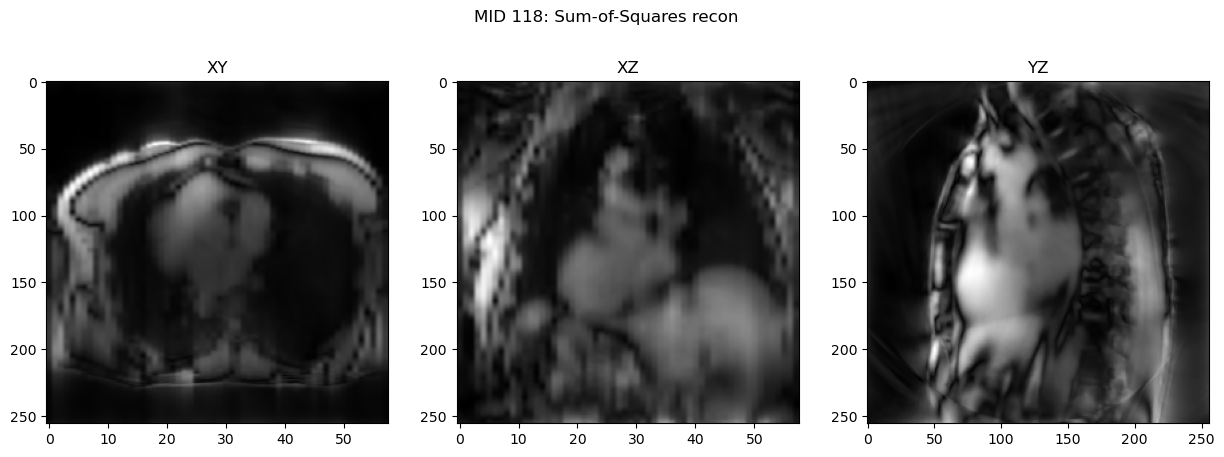

In [ ]:
def calculate_sos_img(recon_all_channels, plot=True):

    # Normalize the intensities on a coil by coil basis
    recon_all_channels_norm = recon_all_channels / np.max(np.abs(recon_all_channels))

    ## Move axis on recon_all_channels_norm so we have in (z, y, x) format
    recon_all_channels_norm = np.moveaxis(recon_all_channels_norm, [0, 1, 2, 3], [0, 3, 1, 2])

    print(recon_all_channels_norm.shape)
    print(np.max(recon_all_channels_norm))

    # SoS
    sos_img = np.sqrt(np.sum(np.abs(recon_all_channels_norm ** 2), axis=0))

    # Apply orientation corrections to sos_img before plotting
    sos_img_oriented = np.fliplr(np.flipud(np.fliplr(np.fliplr(np.flipud(sos_img)))))
    
    return recon_all_channels_norm, sos_img, sos_img_oriented

def display_sos_img(sos_img, x_idx=None, y_idx=None, z_idx=None, title=""):

    # Dimensions
    Nz, Ny, Nx = sos_img.shape

    fig, axs = plt.subplots(1,3, figsize=(15, 5))
    
    ##### sos img is in (z, y, x) 
    Nz, Ny, Nx = sos_img.shape
    aspect  = Nx/Nz
    ## Set indices if not set
    if z_idx is None:
        z_idx = Nz//2
    if y_idx is None:
        y_idx = Ny //2
    if x_idx is None:
        x_idx = Nx//2
    
    axs[0].imshow((sos_img[z_idx, :, :]), cmap='gray', aspect=Nx/Ny)
    axs[0].set_title("XY")
    axs[1].imshow((sos_img[ :, y_idx, :]), cmap='gray', aspect=aspect)
    axs[1].set_title("XZ")
    axs[2].imshow((sos_img[:, :, x_idx]), cmap='gray', aspect=Ny/Nz)
    axs[2].set_title("YZ")

    fig.suptitle(f'MID 118: Sum-of-Squares recon {title}')
    plt.show()


## axes in recon_all_channels_loaded 
recon_all_channels_norm, sos_img, sos_img_oriented = calculate_sos_img(recon_all_channels_loaded)
display_sos_img(sos_img_oriented)
## sos image now in (z, y, x) formate
## recon_all_channels_norm is 

In [ ]:
# def calculate_sos_img(recon_all_channels, plot=True):

#     # Normalize the intensities on a coil by coil basis
#     recon_all_channels_norm = recon_all_channels / np.max(np.abs(recon_all_channels))

#     ## Move axis on recon_all_channels_norm so we have in (z, y, x) format
#     recon_all_channels_norm = np.moveaxis(recon_all_channels_norm, [0, 1, 2, 3], [0, 3, 1, 2])

#     print(recon_all_channels_norm.shape)
#     print(np.max(recon_all_channels_norm))

#     # SoS
#     sos_img = np.sqrt(np.sum(np.abs(recon_all_channels_norm ** 2), axis=0))
    
#     return recon_all_channels_norm, sos_img

# def display_sos_img(sos_img, x_idx=None, y_idx=None, z_idx=None, title=""):

#     # Dimensions
#     Nz, Ny, Nx = sos_img.shape

#     fig, axs = plt.subplots(1,3, figsize=(15, 5))
    
#     ##### sos img is in (z, y, x) 
#     Nz, Ny, Nx = sos_img.shape
#     aspect  = Nx/Nz
#     ## Set indices if not set
#     if z_idx is None:
#         z_idx = Nz//2
#     if y_idx is None:
#         y_idx = Ny //2
#     if x_idx is None:
#         x_idx = Nx//2
#     # Apply orientation corrections to sos_img before plotting
#     sos_img_oriented = np.fliplr(np.fliplr(np.flipud(sos_img)))

#     axs[0].imshow(sos_img_oriented[z_idx, :, :], cmap='gray', aspect=Nx/Ny)
#     axs[0].set_title("XY")
#     axs[1].imshow(sos_img_oriented[:, y_idx, :], cmap='gray', aspect=aspect)
#     axs[1].set_title("XZ")
#     axs[2].imshow(sos_img_oriented[:, :, x_idx], cmap='gray', aspect=Ny/Nz)
#     axs[2].set_title("YZ")

#     fig.suptitle(f'MID 118: Sum-of-Squares recon {title}')
#     plt.show()


# ## axes in recon_all_channels_loaded 
# recon_all_channels_norm, sos_img = calculate_sos_img(recon_all_channels_loaded)
# display_sos_img(sos_img)

## 2. Low res coil sensitivities

In [101]:
low_res_coil_recons.shape

(15, 64, 32, 32)

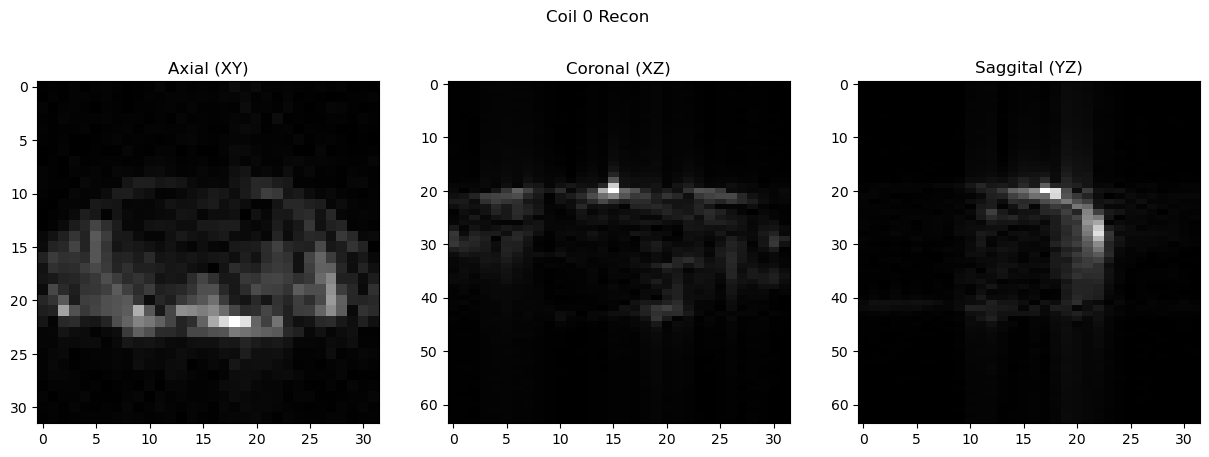

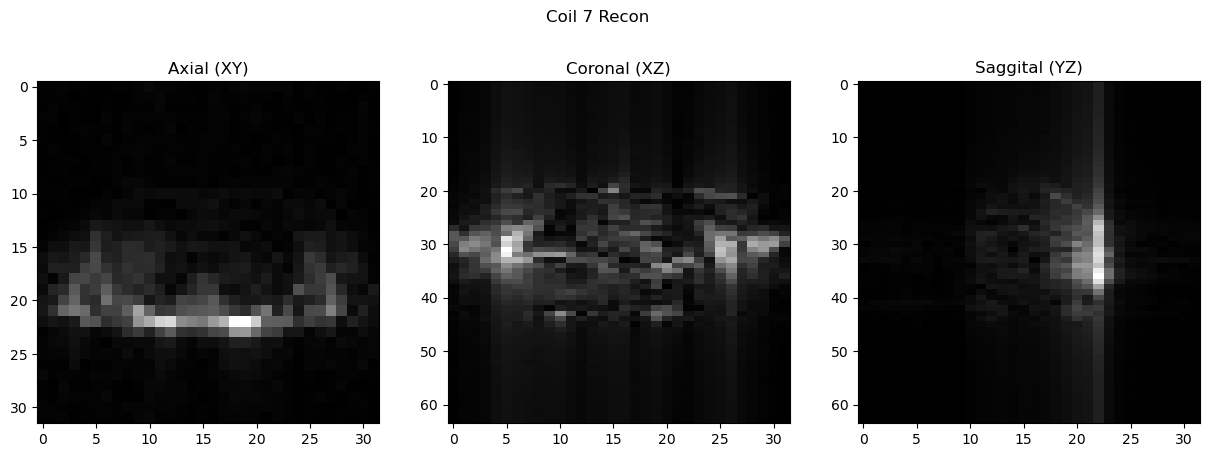

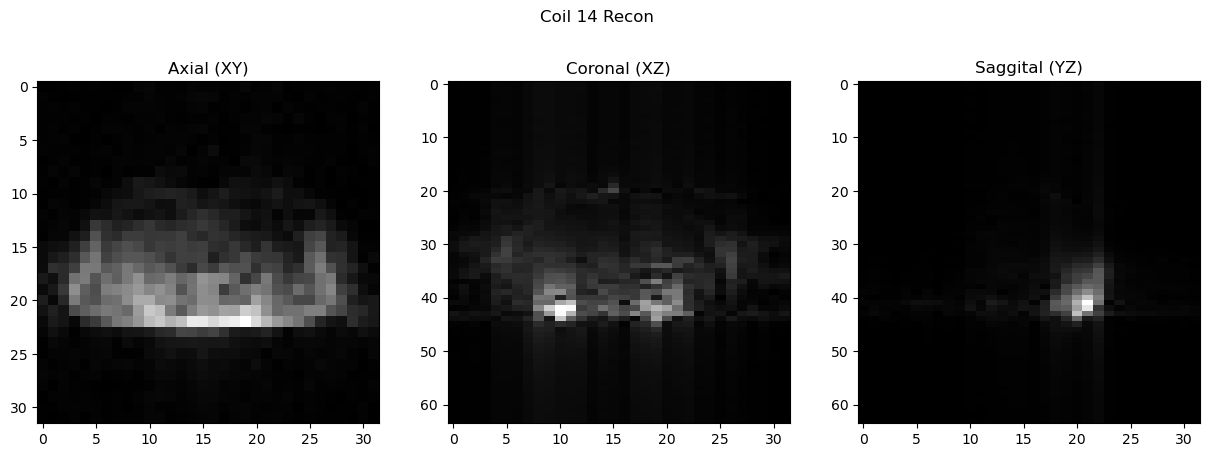

In [ ]:
def change_orientation_coil_data(coil_recons):
    # Move axes 
    coil_recons = np.moveaxis(coil_recons, [0, 1, 2, 3], [0, 1, 3, 2])
    coil_recons = np.transpose(coil_recons, (0, 1, 3, 2))
    coil_recons = np.rot90(coil_recons, k=3, axes=(2,3))
    # Flip dimension at index 3 (last axis) upside down
    coil_recons = np.flip(coil_recons, axis=1)
    return coil_recons

def display_coil_data(img, coil_idx, z_idx=None, y_idx=None, x_idx=None, title=""):
    _, Nz, Ny, Nx = img.shape
    # img =  np.zeros((Nz, Ny, Nx))
    if z_idx is None:
        z_idx = Nz//2
    if y_idx is None:
        y_idx = Ny //2
    if x_idx is None:
        x_idx = Nx//2

    fig, axs = plt.subplots(1,3, figsize=(15, 5))
    aspect = Nx / Nz
    axs[0].imshow(img[coil_idx, z_idx, :, :], cmap='gray', aspect=1.)
    axs[0].set_title("Axial (XY)")
    axs[1].imshow((img[coil_idx, :, y_idx, :]), cmap='gray', aspect=aspect)
    axs[1].set_title("Coronal (XZ)")
    axs[2].imshow((img[coil_idx, :, :, x_idx]), cmap='gray', aspect=aspect)
    axs[2].set_title("Saggital (YZ)")
    

    fig.suptitle(f"Coil {coil_idx} Recon {title}")
    plt.show()

low_res_coils_reshaped = change_orientation_coil_data(low_res_coil_recons)

display_coil_data(low_res_coils_reshaped, coil_idx=0)
display_coil_data(low_res_coils_reshaped, coil_idx=7)
display_coil_data(low_res_coils_reshaped, coil_idx=14)

In [1]:
# def calculate_sos_img_new(low_res_coil_data, plot=True):

#     # SoS
#     sos_img = np.sqrt(np.sum(np.abs(low_res_coil_data ** 2), axis=0))

#     # Apply orientation corrections to sos_img before plotting
#     sos_img_oriented = np.fliplr(np.flipud(np.fliplr(np.fliplr(np.flipud(sos_img)))))
    
#     return sos_img, sos_img_oriented


# sos_img_coils_test, sos_img_oriented_coils_test = calculate_sos_img_new(low_res_coils_reshaped)
# display_sos_img(sos_img_coils_test, title="low_res_coils")

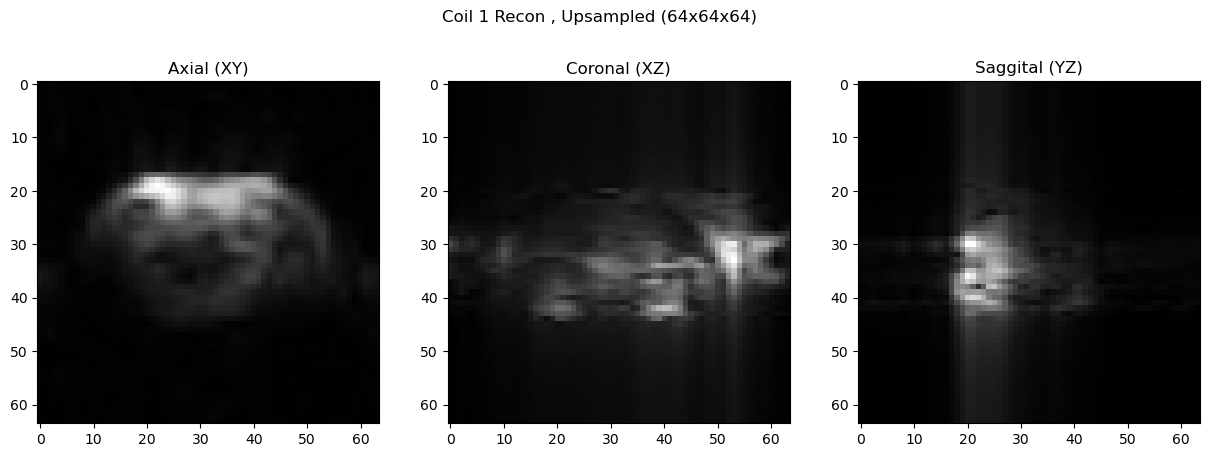

high_res_reshaped.shape = (256, 256, 58)


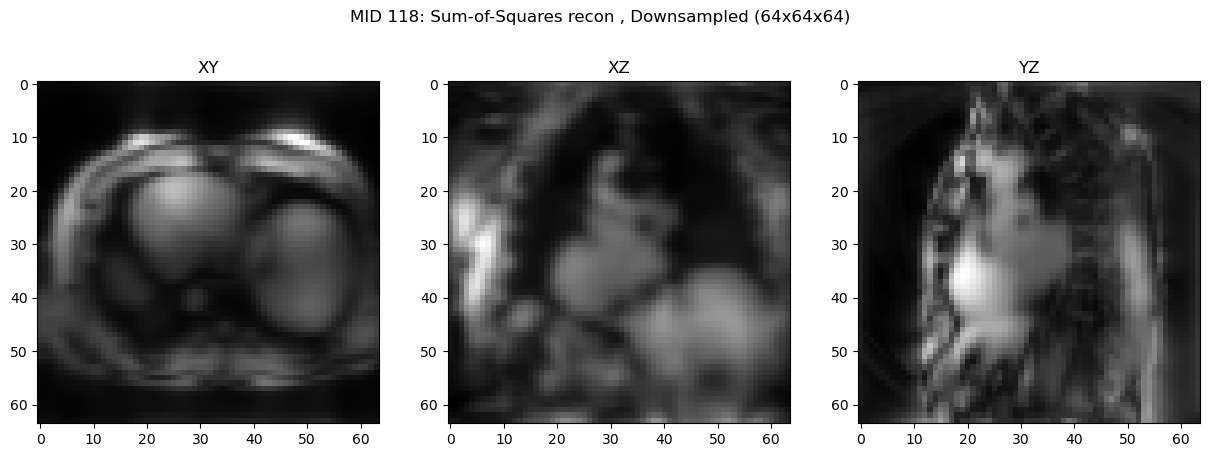

In [136]:
def upsample(low_res_coil_recons, target_shape):
    ncoils = low_res_coil_recons.shape[0]

    # Only upsample spatial dims, not coil dim
    zoom_factors = [1] + [t/s for t, s in zip(target_shape[-3:], low_res_coil_recons.shape[-3:])]
    upsampled = zoom(low_res_coil_recons, zoom_factors, order=1)  # order=1: linear interpolation
    return upsampled


def downsample_and_smooth(high_res_recon, low_res_coil_recons):
    ## Data dimensions different for both
    ncoils, zl, yl, xl = low_res_coil_recons.shape

    ## swap dims of high-res recon to be correct
    yh, zh, xh = high_res_recon.shape

    high_res_rshp = np.swapaxes(high_res_recon, 1, 0)
    print(f'high_res_reshaped.shape = {high_res_rshp.shape}')

    lowres_dims = [zl, yl, xl]
    highres_dims = [zh, yh, xh]

    # Calculate zoom factors for downsampling (output_shape / input_shape)
    zoom_factors = [lowres_dims[i] / highres_dims[i] for i in range(len(highres_dims))]

    # Apply Gaussian filter for anti-aliasing before downsampling
    blurred = ndimage.gaussian_filter(high_res_recon, sigma=[1, 1, 1])

    # Downsample using zoom
    downsampled = zoom(blurred, zoom_factors, order=1)
    return downsampled

## 1. Upsample low-res coil recons so that we have isotropic resolution to make division easier
low_res_isotropic = upsample(low_res_coils_reshaped, target_shape=(64,64,64))
display_coil_data(low_res_isotropic, coil_idx=1, z_idx=40, title=", Upsampled (64x64x64)")

## 2. Downsample high resolution image to prepare for coil sensitivity calculation
high_res_downsampled = downsample_and_smooth(sos_img_oriented, low_res_isotropic)
display_sos_img(high_res_downsampled, z_idx=40, title=", Downsampled (64x64x64)")

### Divide SoS image by coil recons

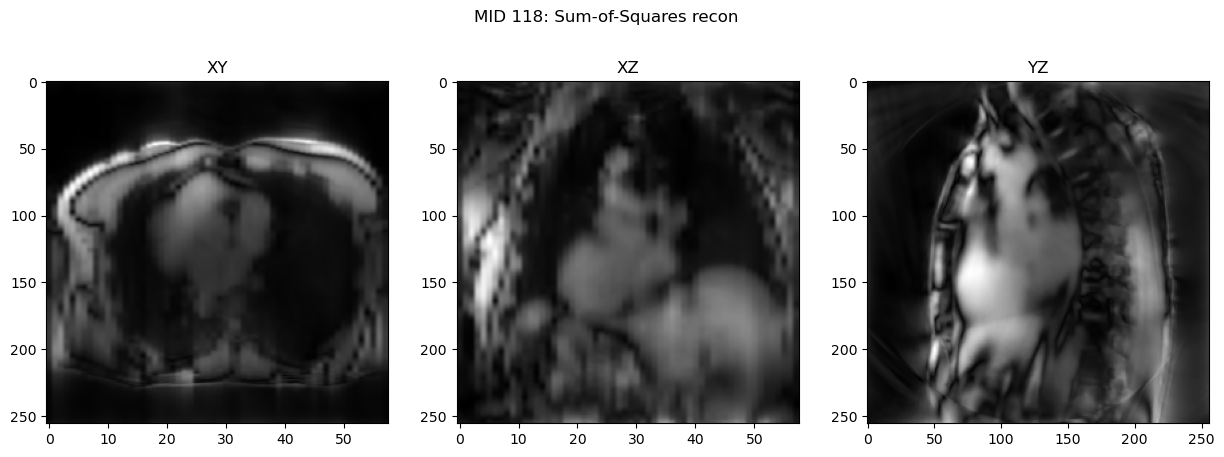

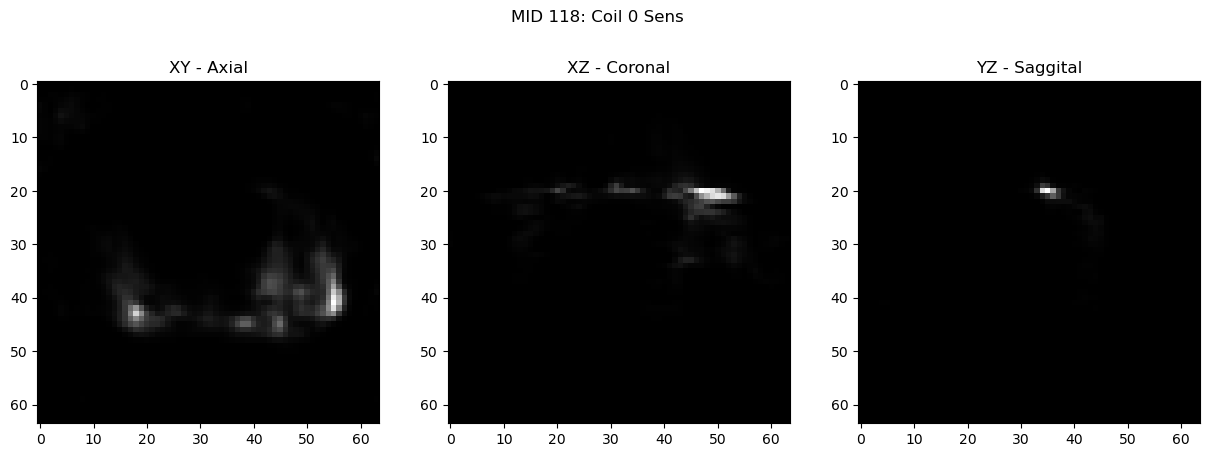

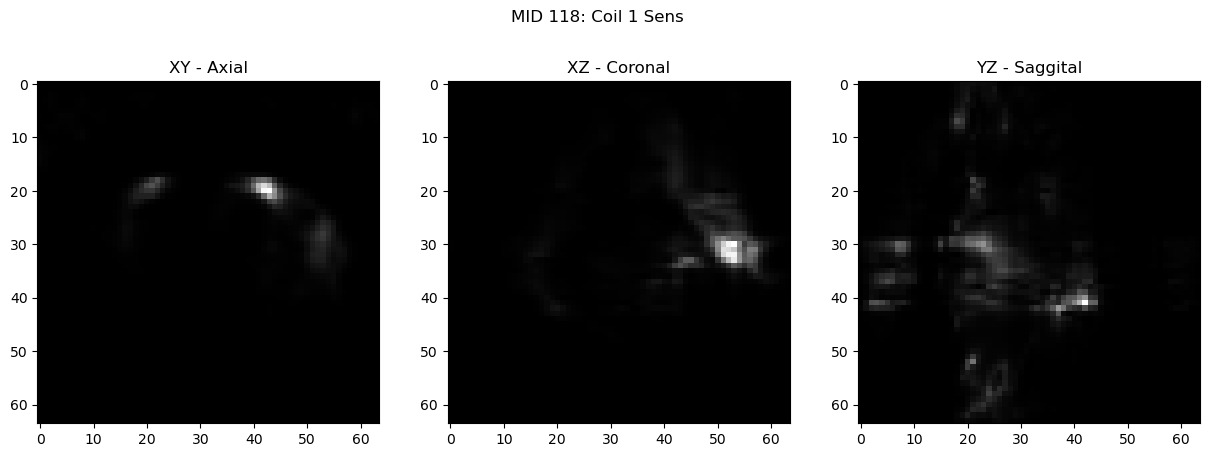

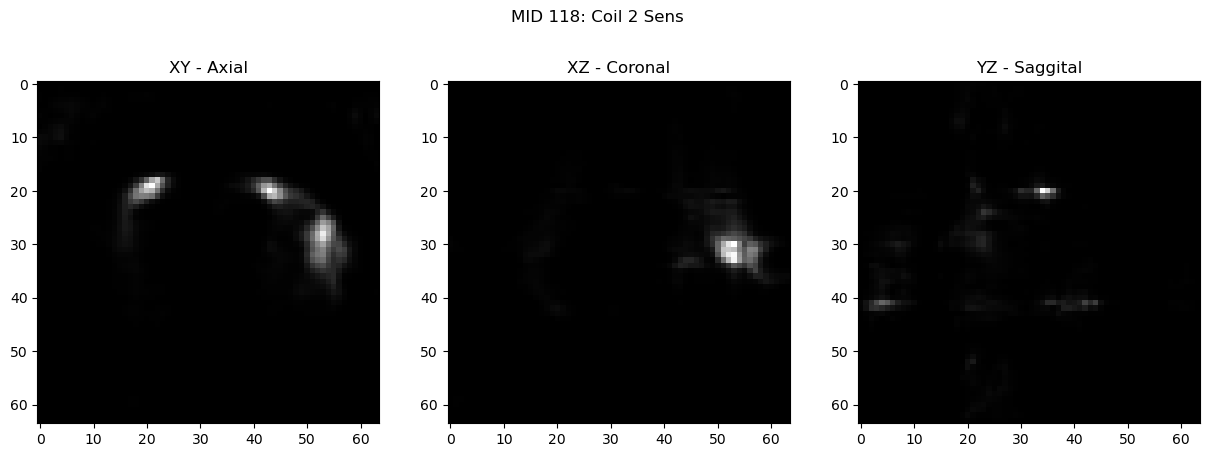

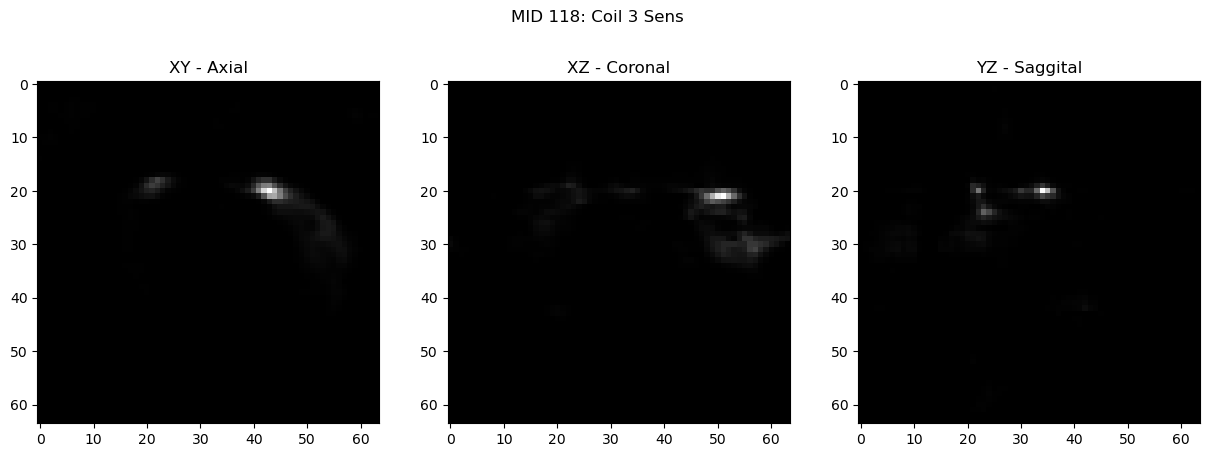

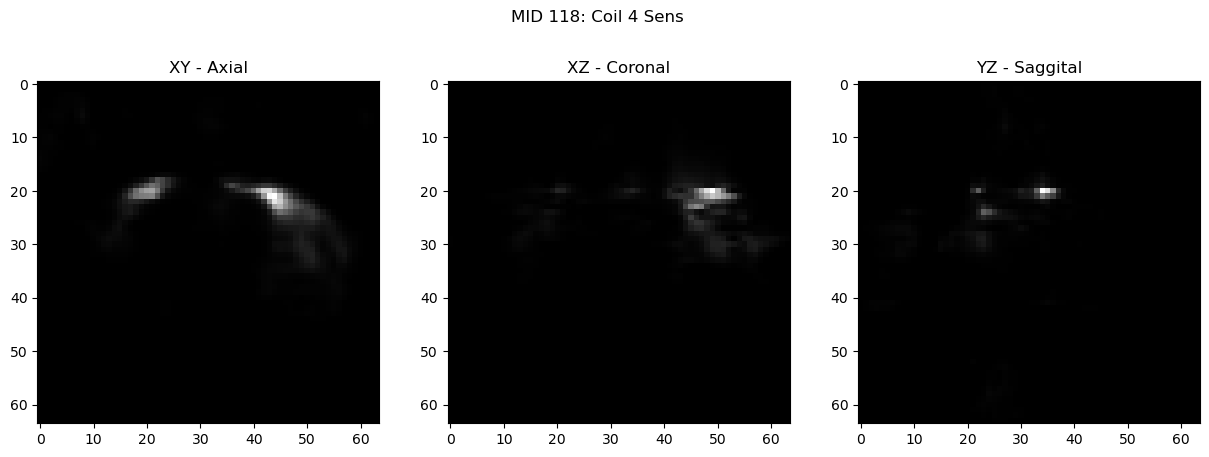

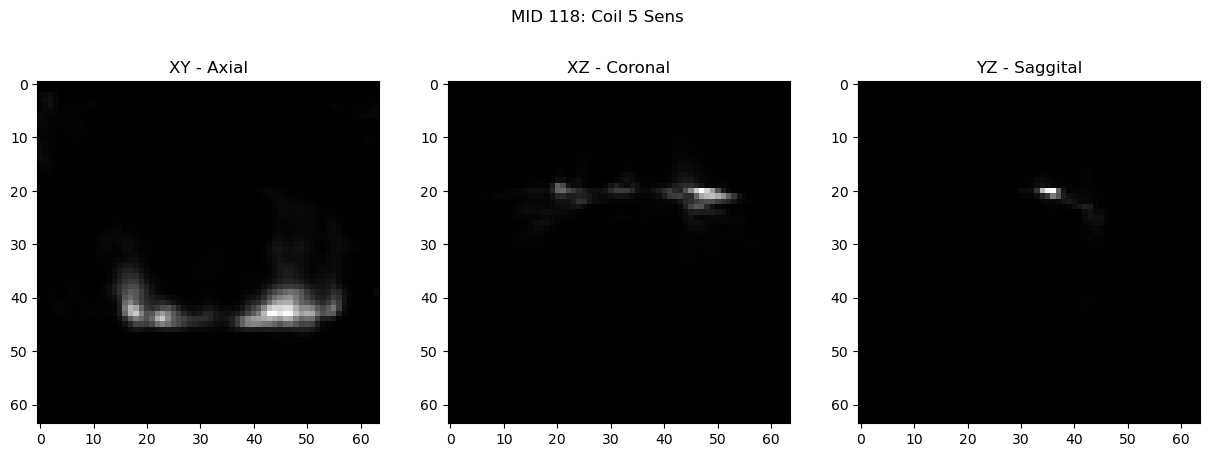

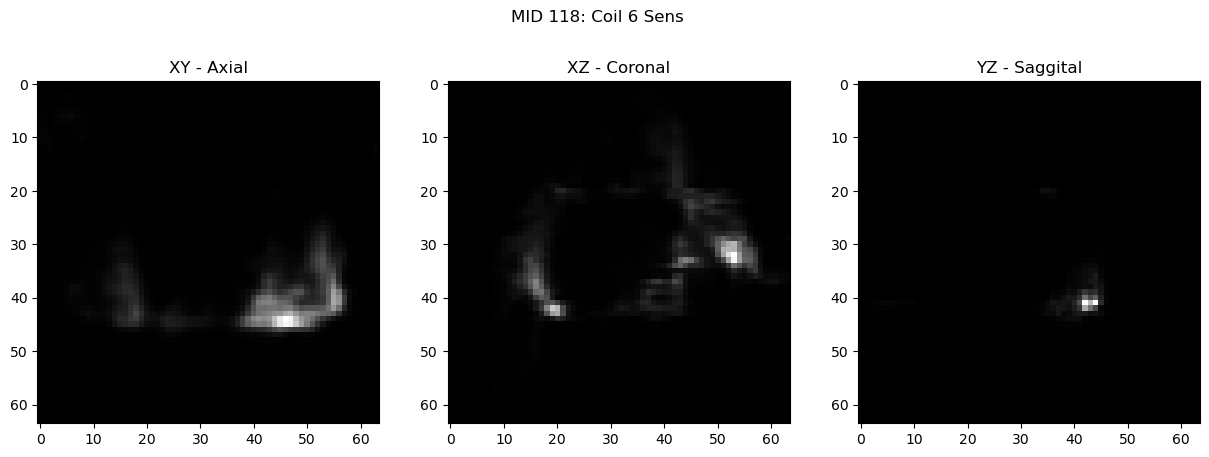

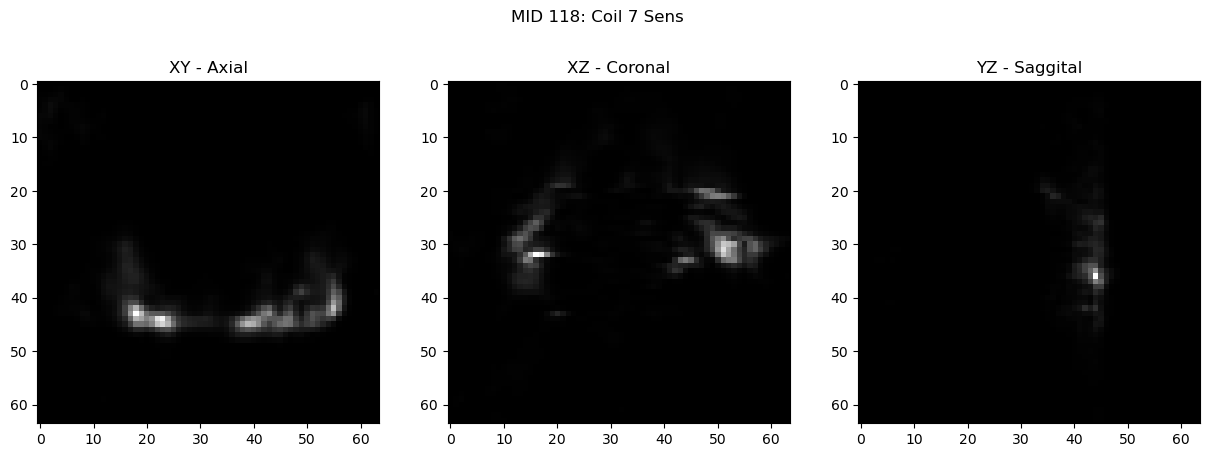

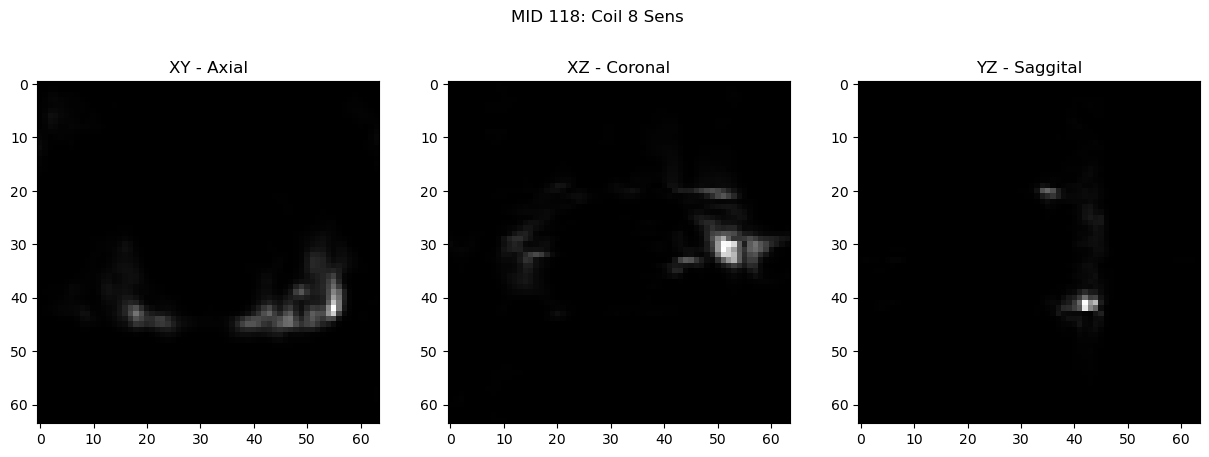

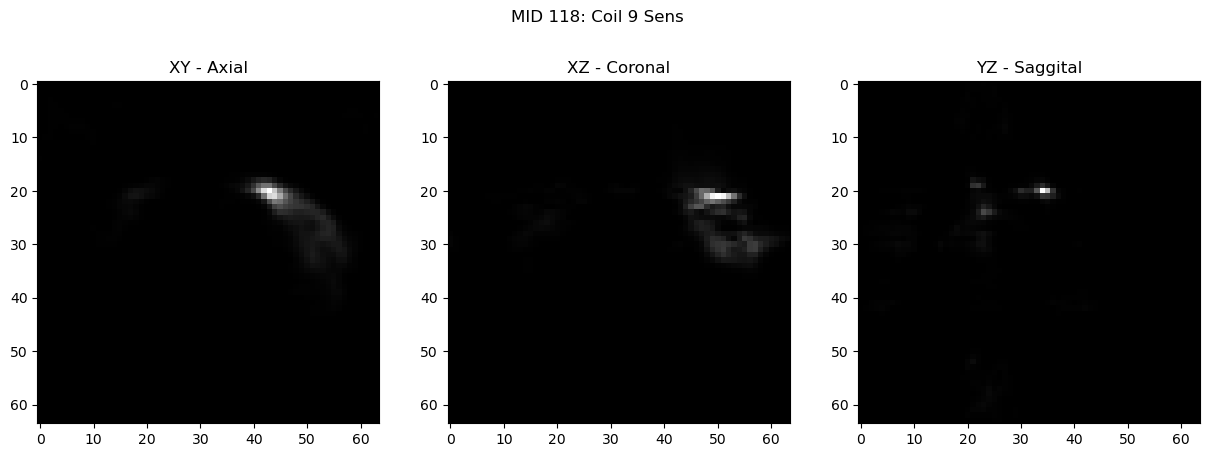

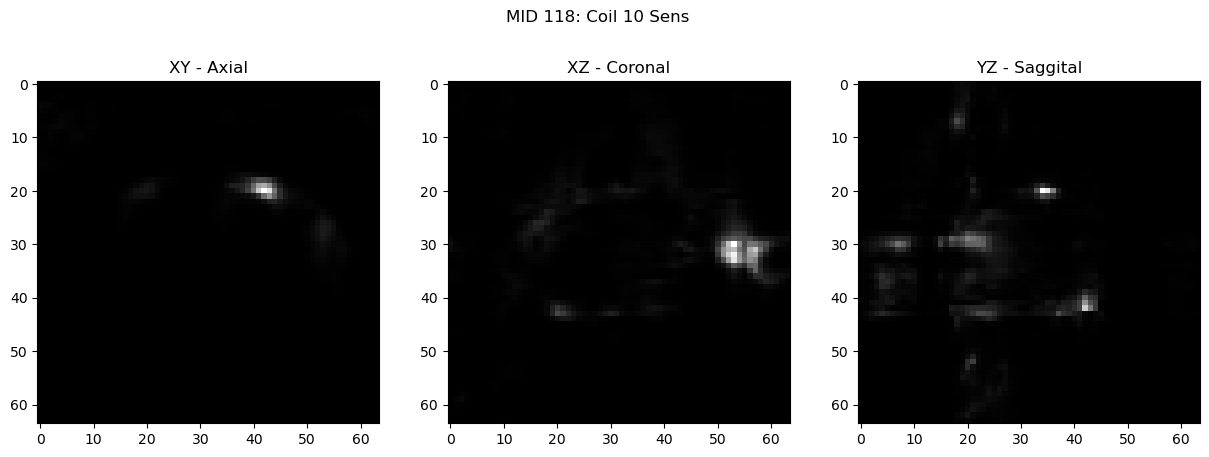

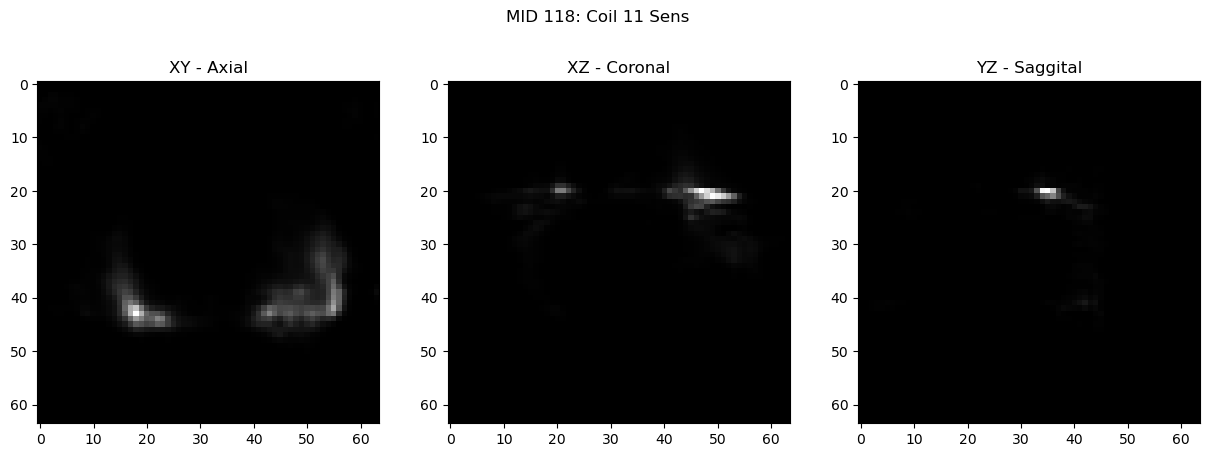

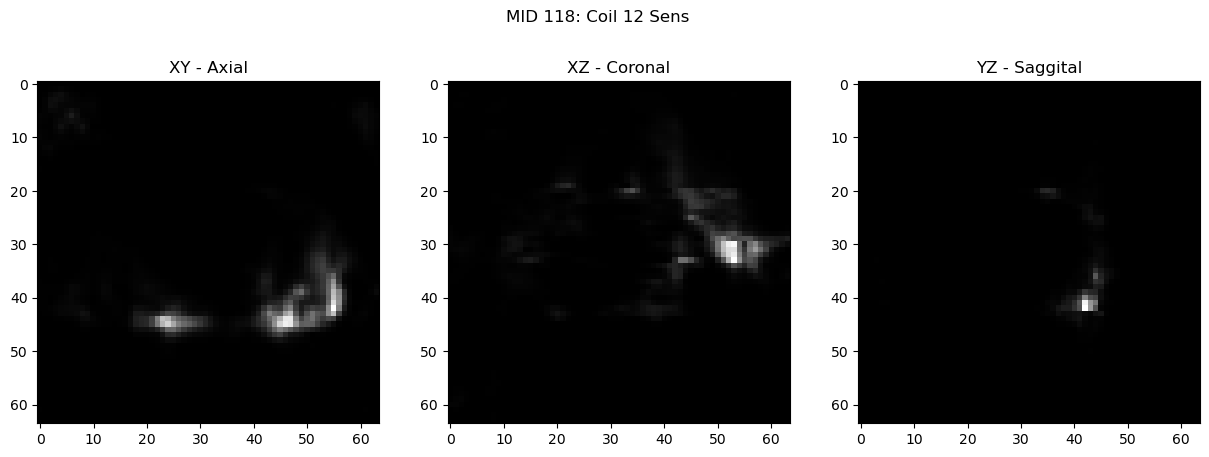

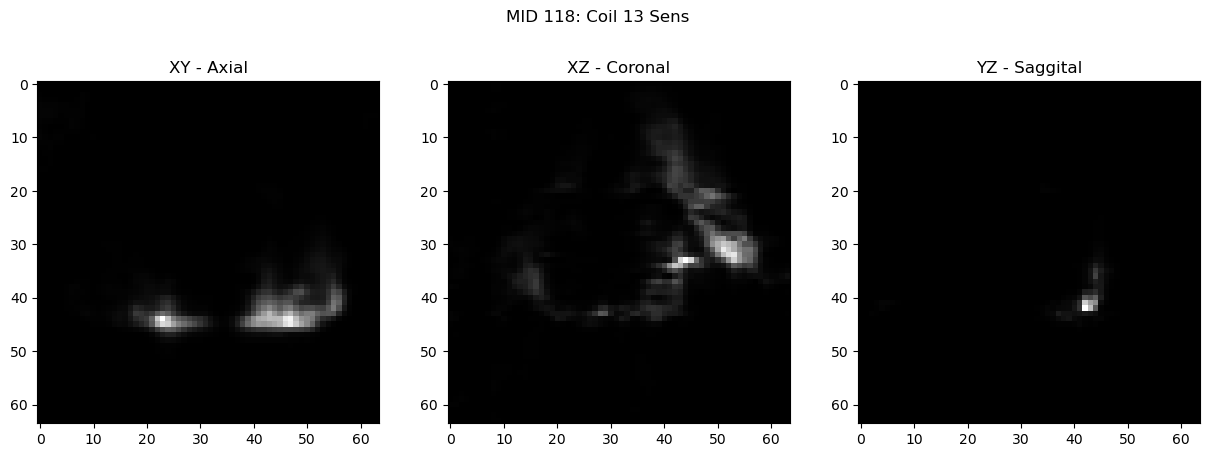

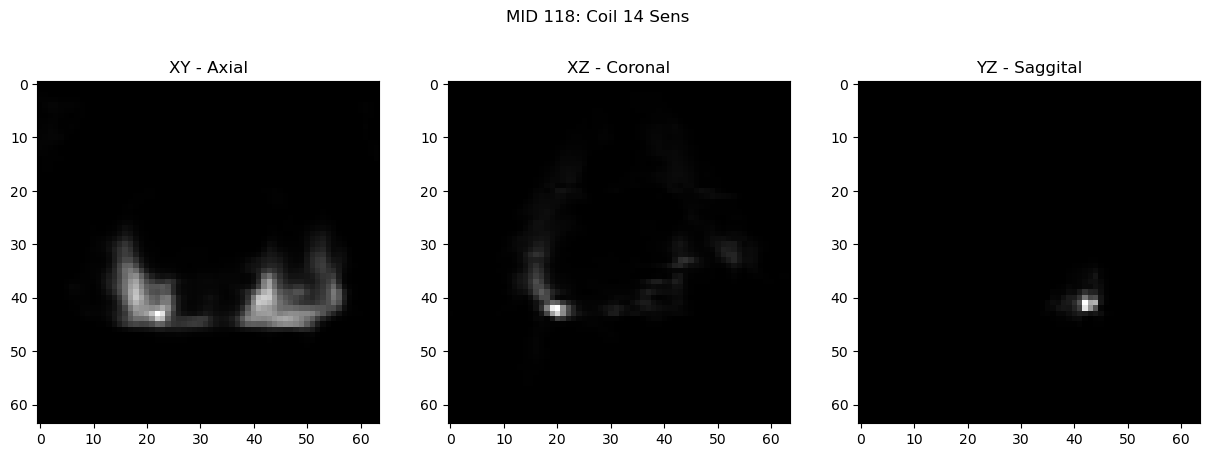

In [ ]:
def calculate_coil_sens(low_res_coils, high_res_sos, plot=True, coil_idx=None, z_idx=None, y_idx=None, x_idx=None):
    ## Initialize empty array for coil sens images
    ncoils, Nz, Ny, Nx = low_res_coils.shape
    coil_sens_images = np.zeros((ncoils, Nz, Ny, Nx))

    ## Divide individual coil images by sum of squares
    for i in range(ncoils):
        # calculate raw sensitivities
        sens = low_res_coils[i] / high_res_sos
        
        # square the magnitude to suppress noise, keep original phase
        sens_mag = np.abs(sens)
        sens_phase = np.angle(sens)
        
        # Square the magnitude to suppress small values
        sens_mag_squared = sens_mag ** 2
        
        # reconstruct with og phase
        coil_sens_images[i] = np.abs(sens_mag_squared * np.exp(1j * sens_phase))
    
    if plot is True:
        ## Set indices if not set
        if z_idx is None:
            z_idx = Nz//2
        if y_idx is None:
            y_idx = Ny //2
        if x_idx is None:
            x_idx = Nx//2

        if coil_idx is None:
            for i in range(ncoils):
                fig, axs = plt.subplots(1,3, figsize=(15, 5))
                aspect = Nz /Nx

                axs[0].imshow(coil_sens_images[i, z_idx, :, :], cmap='gray', aspect=1.)
                axs[0].set_title("XY - Axial")
                axs[1].imshow(coil_sens_images[i, :, y_idx, :], cmap='gray', aspect=aspect)
                axs[1].set_title("XZ - Coronal")
                axs[2].imshow(coil_sens_images[i, :, :, x_idx], cmap='gray', aspect=aspect)
                axs[2].set_title("YZ - Saggital")    
                fig.suptitle(f"MID 118: Coil {i} Sens ")
                plt.show()
        
        if coil_idx is not None:
            fig, axs = plt.subplots(1,3, figsize=(15, 5))
            aspect = Nz /Nx
            axs[0].imshow(coil_sens_images[coil_idx, z_idx, :, :], cmap='gray', aspect=1.)
            axs[0].set_title("XY - Axial")
            axs[1].imshow(coil_sens_images[coil_idx, :, y_idx, :], cmap='gray', aspect=aspect)
            axs[1].set_title("XZ - Coronal")
            axs[2].imshow(coil_sens_images[coil_idx, :, :, x_idx], cmap='gray', aspect=aspect)
            axs[2].set_title("YZ - Saggital")
            fig.suptitle(f"MID 118: Coil {coil_idx} Sensitivity ")
            plt.show()

display_sos_img(sos_img_oriented)
calculate_coil_sens(low_res_isotropic, high_res_downsampled)